In [2]:
!nvidia-smi

Tue Mar 10 09:35:42 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 575.51.03              Driver Version: 575.51.03      CUDA Version: 12.9     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA GeForce RTX 3070        Off |   00000000:17:00.0 Off |                  N/A |
| 45%   49C    P2             44W /  270W |    4632MiB /   8192MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [3]:
import os
os.environ["CUDA_VISIBLE_DEVICES"] = "0" 
import clickpoints
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import glob
import random
from matplotlib.patches import Ellipse
from matplotlib.patches import Rectangle
from ultralytics import YOLO
import os, yaml
import numpy as np
from PIL import Image
import math
from tqdm import tqdm
from sahi import AutoDetectionModel
from sahi.utils.cv import visualize_object_predictions
from sahi.predict import get_sliced_prediction
from pathlib import Path
import torch
%matplotlib inline

In [3]:
print(torch.cuda.is_available(), torch.cuda.device_count())

True 1


In [8]:
colors = {
    'female': '#1F77B4',
    'male': '#FF7F0E',
    'pup': '#2CA02C',
    'giant petrel': '#9467bd', 
    'skua': '#8C564B',
    'sheathbill': '#e377c2', 
    'fwb': 'salmon',
    'ssb': '#5254A3'
}
labels = {
    'male': 'adult male',
    'female': 'adult female',
    'pup': 'pup',
    'giant petrel': 'giant petrel',
    'sheathbill': 'snowy sheathbill',
    'skua': 'brown skua',
}
fontsize = 11

In [4]:
def load_dataset(folder_path):
    """
    Reads all .cdb files in the specified folder and aggregates them 
    into a single pandas DataFrame and an array of images.
    """
    
    all_rects = []
    all_images = []
    
    # Counter to create a unique image_id across all files 
    # (since every individual cdb will start at id 1)
    global_image_id = 0
    
    # Get a sorted list of all cdb files to ensure consistent order
    cdb_files = sorted([f for f in os.listdir(folder_path) if f.endswith('.cdb')])
    

    for cdb_file in tqdm(cdb_files):
        full_cdb_path = os.path.join(folder_path, cdb_file)
        
        # Open the individual CDB
        try:
            with clickpoints.DataFile(full_cdb_path) as cdb:
                # Iterate through images in this specific CDB
                for img in cdb.getImages():
                    
                    # Store image data
                    all_images.append(img.data)
                    
                    # Process rectangles for this image
                    for rect in img.rectangles:
                        all_rects.append([
                            img.filename,       # filename
                            img.timestamp,      # timestamp
                            rect.type.name,     # class_name
                            rect.x,             # x
                            rect.y,             # y
                            rect.width,         # width
                            rect.height,        # height
                            global_image_id     # unique global image_id
                        ])
                    
                    # Increment global ID after processing an image
                    global_image_id += 1
                    
        except Exception as e:
            print(f"Error reading {cdb_file}: {e}")

    # Convert list of images to numpy array
    # Note: This assumes all images have the same dimensions. 
    # If dimensions vary, keep it as a list or use object array.
    try:
        images = np.array(all_images)
    except ValueError:
        print("Warning: Images have different dimensions, returning list instead of numpy array.")
        images = all_images

    # Create the DataFrame
    gt = pd.DataFrame(
        all_rects,
        columns=["filename", "timestamp", "class_name", "x", "y", "width", "height", "image_id"]
    )

    return gt, images


# Load Annotations and Images

In [5]:
folder_path = "./data"  # Change this to your actual folder path
gt, images = load_dataset(folder_path)

100%|██████████| 113/113 [00:47<00:00,  2.40it/s]


In [6]:
gt.class_name.unique()

array(['male', 'penguin', 'sheathbill', 'female', 'leopard seal', 'elephant seal', 'pup', 'giant petrel', 'skua'], dtype=object)

In [7]:
gt['class_name'].value_counts()

class_name
pup              3436
female           3383
male             2742
penguin           720
sheathbill        337
elephant seal      39
skua               14
giant petrel       12
leopard seal        3
Name: count, dtype: int64

In [8]:
#drop leopard seals, not interested and too few examples
gt = gt[gt["class_name"] != "leopard seal"]

In [9]:
gt

,filename,timestamp,class_name,x,y,width,height,image_id
0,2020-11-08_12-00-00.jpg,2020-11-08 12:00:00,male,1753.268019,1901.361772,95.422769,45.023419,0
1,2020-11-08_12-00-00.jpg,2020-11-08 12:00:00,male,2476.020616,2374.437199,104.965045,96.833950,0
2,2020-11-08_12-00-00.jpg,2020-11-08 12:00:00,male,2802.742800,2270.211344,188.493567,103.486664,0
3,2020-11-08_12-00-00.jpg,2020-11-08 12:00:00,male,3000.106652,2446.877864,138.135492,125.131253,0
4,2020-11-08_12-00-00.jpg,2020-11-08 12:00:00,male,3583.838850,2405.975410,125.418144,114.583187,0
...,...,...,...,...,...,...,...,...
10681,2021-01-01_14-02-29.jpg,2021-01-01 14:02:29,sheathbill,4235.415962,738.935778,24.041375,17.515859,112
10682,2021-01-01_14-02-29.jpg,2021-01-01 14:02:29,sheathbill,4243.658719,710.086127,19.233100,13.394481,112
10683,2021-01-01_14-02-29.jpg,2021-01-01 14:02:29,sheathbill,4226.486308,692.570268,14.424825,16.142066,112
10684,2021-01-01_14-02-29.jpg,2021-01-01 14:02:29,sheathbill,4177.373213,711.803368,21.637238,15.111722,112


In [10]:
# this defines a color for each class: helper function for later
classes = sorted(gt.class_name.unique())
mpl_cycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
colors = {
    cls: mpl_cycle[i % len(mpl_cycle)]
    for i, cls in enumerate(classes)
}

# Create training / validation / test dataset

In [12]:
def create_yolo_dataset(df, images, output_folder,
                        padding=True, split=[0.7,0.15,0.15],
                        tile_size=(512,512), seed=42):
    # 1) build image_id → PIL.Image map
    img_map = {}
    if isinstance(images, np.ndarray):
        # assume images.shape == (N, H, W, C)
        ids = sorted(df.image_id.unique())
        assert len(ids) <= images.shape[0], "Not enough images in array"
        for idx, img_id in enumerate(ids):
            img_map[img_id] = Image.fromarray(images[idx])
    elif isinstance(images, (list, tuple)):
        ids = sorted(df.image_id.unique())
        assert len(ids) <= len(images), "Not enough images in list"
        for idx, img_id in enumerate(ids):
            img_map[img_id] = images[idx]
    elif isinstance(images, dict):
        for img_id, grp in df.groupby('image_id'):
            fn = grp.filename.iat[0]
            img_map[img_id] = images[fn]
    else:
        raise TypeError("`images` must be ndarray, list/tuple, or dict")

    # 2) class→index
    classes = sorted(df.class_name.unique())
    cls_map = {c: i for i, c in enumerate(classes)}

    # 3) make output directories
    for part in ('training','validation','test'):
        os.makedirs(f"{output_folder}/images/{part}", exist_ok=True)
        os.makedirs(f"{output_folder}/labels/{part}", exist_ok=True)

    # 4) collect all crops & labels
    crops = []
    for img_id, grp in tqdm(df.groupby('image_id')):
        img = img_map[img_id]
        W, H = img.size

        # slide window
        for y0 in range(0, H, tile_size[1]):
            for x0 in range(0, W, tile_size[0]):
                crop = img.crop((x0, y0, x0 + tile_size[0], y0 + tile_size[1]))
                if padding and crop.size != tile_size:
                    bg = Image.new(img.mode, tile_size, 0)
                    bg.paste(crop, (0, 0))
                    crop = bg

                labels = []
                for _, r in grp.iterrows():
                    cx = r.x + r.width/2
                    cy = r.y + r.height/2
                    if x0 <= cx < x0 + tile_size[0] and y0 <= cy < y0 + tile_size[1]:
                        xc = (cx - x0) / tile_size[0]
                        yc = (cy - y0) / tile_size[1]
                        wc = r.width  / tile_size[0]
                        hc = r.height / tile_size[1]
                        labels.append(
                            f"{cls_map[r.class_name]} "
                            f"{xc:.6f} {yc:.6f} {wc:.6f} {hc:.6f}"
                        )

                base = os.path.splitext(grp.filename.iat[0])[0]
                name = f"{base}_{x0}_{y0}.jpg"
                crops.append((crop, labels, name))

    # 5) shuffle & split at crop level
    rng = np.random.default_rng(seed)
    rng.shuffle(crops)
    n       = len(crops)
    n_train = int(split[0] * n)
    n_val   = int(split[1] * n)

    assignments = [
        ('training',   crops[:n_train]),
        ('validation', crops[n_train:n_train + n_val]),
        ('test',       crops[n_train + n_val:])
    ]

    # 6) save images + labels
    for part, subset in assignments:
        for img_crop, labels, name in subset:
            img_crop.save(os.path.join(output_folder, 'images', part, name))
            lbl_file = os.path.join(output_folder, 'labels', part, name.replace('.jpg', '.txt'))
            with open(lbl_file, 'w') as f:
                f.write('\n'.join(labels))

    # 7) write data.yaml
    data = {
        'train': os.path.join('images', 'training'),
        'val':   os.path.join('images', 'validation'),
        'test':  os.path.join('images', 'test'),
        'nc':    len(classes),
        'names': classes
    }
    with open(os.path.join(output_folder, 'data.yaml'), 'w') as f:
        yaml.dump(data, f, sort_keys=False)
    return data

In [13]:
# creating the dataset:: no overlap, 80% to train, 20% validation, no test set
data = create_yolo_dataset(
    df            = gt,
    images        = images,
    output_folder = "yolo/data",
    padding       = True,
    split         = [0.8, 0.2, 0],
    tile_size     = (512, 512),
    seed          = 42,
)

100%|██████████| 3/3 [01:40<00:00, 33.36s/it]


In [14]:
# debugging function: check if the "encoding" went correct
def plot_random_yolo_samples(output_folder, n=5, ncols=5, seed=None):
    """
    Plots `n` random YOLO‐formatted images with bounding boxes
    loaded from `output_folder` (with `images/` and `labels/` subdirs),
    and adds a legend mapping each class to its color.
    """
    # Gather all image file paths
    image_paths = glob.glob(os.path.join(output_folder, 'images', '*', '*.jpg'))
    if not image_paths:
        raise FileNotFoundError(f"No images found in {output_folder}/images")
    
    # Randomly select n images
    rng    = np.random.default_rng(seed)
    chosen = rng.choice(image_paths, size=min(n, len(image_paths)), replace=False)
    
    # Setup grid
    n_images = len(chosen)
    nrows    = max(1, math.ceil(n_images / ncols))
    fig, axes = plt.subplots(nrows, ncols, figsize=(ncols*4, nrows*4))
    axes = np.array(axes).reshape(-1)
    for ax in axes[n_images:]:
        ax.axis('off')
    
    # Plot images + boxes
    for ax, img_path in zip(axes, chosen):
        img = Image.open(img_path)
        W, H = img.size
        ax.imshow(img); ax.axis('off')
        
        rel     = os.path.relpath(img_path, os.path.join(output_folder,'images'))
        lbl_path= os.path.join(output_folder,'labels',rel).replace('.jpg','.txt')
        if os.path.exists(lbl_path):
            with open(lbl_path) as f:
                for line in f:
                    cls, xc, yc, w, h = map(float, line.split())
                    xc, yc = xc*W, yc*H
                    w, h   = w*W, h*H
                    x0, y0 = xc-w/2, yc-h/2
                    class_name = classes[int(cls)]
                    rect = Rectangle(
                        (x0,y0), w, h,
                        edgecolor=colors[class_name],
                        fill=False, linewidth=2
                    )
                    ax.add_patch(rect)
    
    # --- Add legend below all subplots ---
    # create one patch per class
    legend_patches = [
        Rectangle((0,0),1,1, fill=False, edgecolor=colors[c], linewidth=2)
        for c in classes
    ]
    # place legend
    fig.legend(
        legend_patches, classes,
        loc='lower center',
        ncol=len(classes),
        bbox_to_anchor=(0.5, -0.02),
        frameon=False
    )
    # adjust layout to make space for legend
    plt.tight_layout(rect=[0, 0.05, 1, 1])
    plt.show()


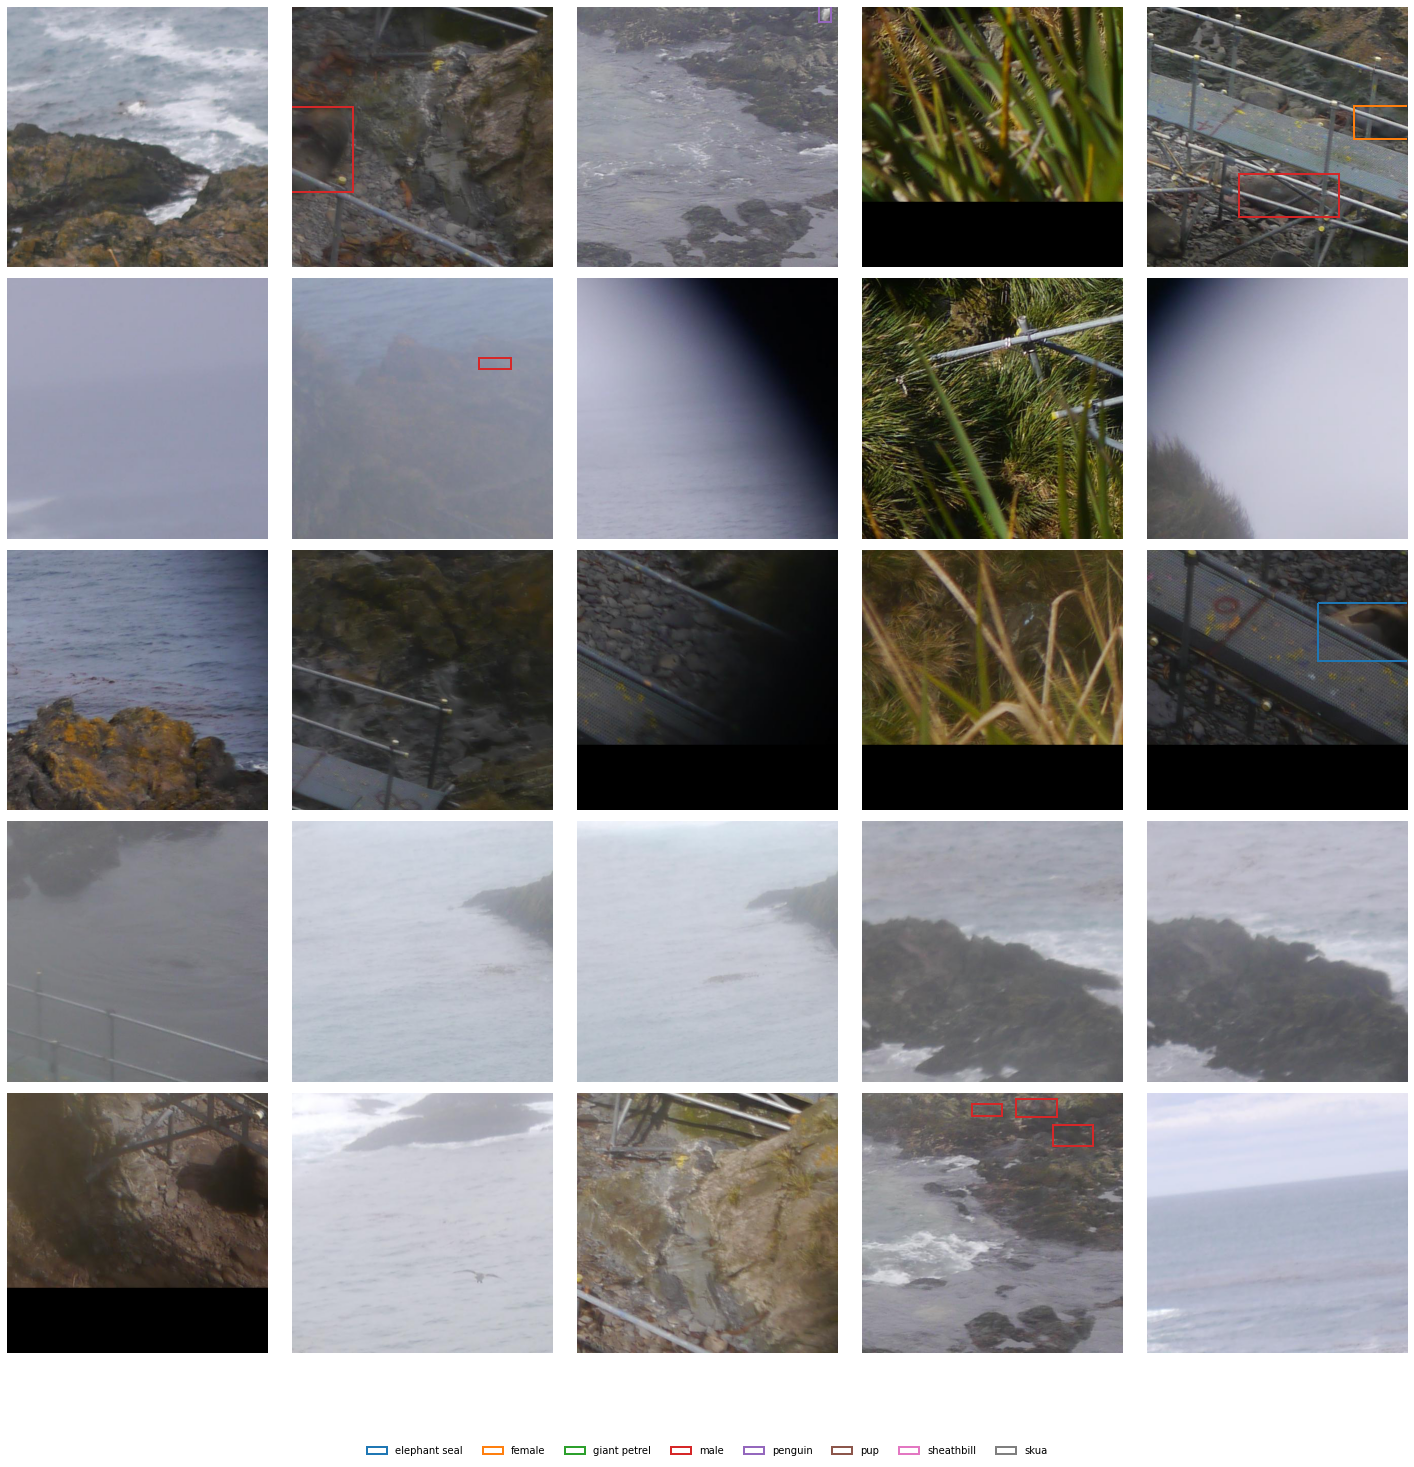

In [15]:
plot_random_yolo_samples(
    "yolo/data",
    n=25, ncols=5
)


# Train YOLO

In [16]:
from ultralytics import YOLO
model = YOLO("yolov8m.pt")
version = 1
# train
model.train(
    data="yolo/data/data.yaml",
    epochs=5,
    imgsz=512,
    batch=16,
#     project="seal",
    name=f"v{version}",
    resume=False,
     # --- augmentation---
    mosaic=1,          # 100% Mosaic
    translate=0.1,     # ±10% translation
    scale=0.2,         # 80–120% scale jitter
    fliplr=0.5,        # 50% horizontal flip
    hsv_h=0.0,         # no hue shift
    hsv_s=0.0,         # no saturation shift
    hsv_v=0.0,         # no brightness shift
    mixup=0.0,
    copy_paste = 0.0,
)

New https://pypi.org/project/ultralytics/8.4.14 available 😃 Update with 'pip install -U ultralytics'
Ultralytics 8.4.12 🚀 Python-3.8.10 torch-2.0.1+cu117 CUDA:0 (NVIDIA GeForce RTX 3070, 7837MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, classes=None, close_mosaic=10, cls=0.5, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=yolo/data/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=5, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.0, hsv_s=0.0, hsv_v=0.0, imgsz=512, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8m.pt, momentum=0.937, mosaic=1, multi_scale=0.0, name=v1, nbs=64, nms=Fal

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3, 4, 5, 6, 7])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7f2bec0c6850>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,

# Validate

In [17]:
version = 1
model = YOLO(f'runs/detect/v{version}/weights/best.pt')
results = model.val(
    data="yolo/data/data.yaml",
#     iou=0.5,
    conf=0.01,
    save=False,
    plots=True,          
    verbose=False
)


Ultralytics 8.4.12 🚀 Python-3.8.10 torch-2.0.1+cu117 CUDA:0 (NVIDIA GeForce RTX 3070, 7837MiB)
Model summary (fused): 93 layers, 25,844,392 parameters, 0 gradients, 78.7 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 241.0±195.3 MB/s, size: 19.1 KB)
val: Scanning /root/seals2/repository/AntarcticFurSealDensity/yolo/data/labels/validation.cache... 2014 images, 1235 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 2014/2014 241.4Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 126/126 6.2it/s 20.4s0.1s
                   all       2014       3540      0.547      0.368      0.403      0.208
Speed: 0.6ms preprocess, 7.4ms inference, 0.0ms loss, 0.7ms postprocess per image
Results saved to /root/seals2/repository/AntarcticFurSealDensity/runs/detect/val


# Run inference

In [18]:
version = 1
detection_model = AutoDetectionModel.from_pretrained(
    model_type="ultralytics",
    model_path=f"runs/detect/v{version}/weights/best.pt",
    confidence_threshold=0.4,
    device="cuda0",
)

In [ ]:
# Helper for consistent class colors
class_colors = {}
def get_color_for_class(class_name):
    if class_name not in class_colors:
        # Generate a random hex color
        class_colors[class_name] = "#" + ''.join([random.choice('0123456789ABCDEF') for j in range(6)])
    return class_colors[class_name]

for img_path in glob.glob("./data/*.jpg"):
    
    # 1. Get filename and directory
    directory = os.path.dirname(img_path)
    filename = os.path.basename(img_path)
    base_name = os.path.splitext(filename)[0]
    
    # 2. Define the new CDB name: [image_name]_v{version}.cdb
    cdb_name = f"{base_name}_v{version}.cdb"
    cdb_path = os.path.join(directory, cdb_name)
    
    print(f"Detecting: {filename} -> Saving to: {cdb_name}")

    # 3. Run Prediction (SAHI)
    result = get_sliced_prediction(
        image=img_path,
        detection_model=detection_model,
        slice_height=512,
        slice_width=512,
        overlap_height_ratio=0.2,
        overlap_width_ratio=0.2,
    )

    # 4. Create and Populate the CDB
    # We open the CDB in 'w' mode (overwrite) or 'a' (append) if preferred. 
    # 'w' is safer for a fresh version export.
    with clickpoints.DataFile(cdb_path, "w") as cdb:

        # Add the image entry (Path is "." because cdb is next to jpg)
        p = cdb.setPath(".")
        img_entry = cdb.setImage(filename, path=p)

        # Process predictions
        for pred in result.object_prediction_list:
            x1, y1, x2, y2 = pred.bbox.to_xyxy()
            width = x2 - x1
            height = y2 - y1
            class_name = pred.category.name

            # Get or create the marker type (ensuring distinct colors)
            # We use the class name from the prediction
            mk_type = cdb.setMarkerType(
                class_name, 
                color=get_color_for_class(class_name), 
                mode=1
            )

            # Write the rectangle
            cdb.setRectangle(
                image=img_entry,
                type=mk_type,
                x=x1,
                y=y1,
                width=width,
                height=height,
                text=f"conf:{pred.score.value:.2f}" # Optional: write confidence as text
            )


print("Batch processing complete.")

Detecting: 2020-12-07_11-24-28.jpg -> Saving to: 2020-12-07_11-24-28_v12.cdb
Performing prediction on 99 slices.
Detecting: 2020-11-27_12-58-38.jpg -> Saving to: 2020-11-27_12-58-38_v12.cdb
Performing prediction on 99 slices.
Detecting: 2020-12-24_16-51-44.jpg -> Saving to: 2020-12-24_16-51-44_v12.cdb
Performing prediction on 99 slices.
